In [1]:
import pandas as pd

data = pd.read_csv("../data/processed/model_dataset_with_holidays.csv", parse_dates=["date"])
data.head()

,date,trend_demand,temp_max,temp_min,temp_avg,precipitation,crowd_index,crowd_level,month,week_of_year,season_spring,season_summer,season_winter,is_holiday
0,2021-01-17,0.197531,9.000000,3.657143,0.156558,0.440000,0.257733,Low,1,2,False,False,True,0
1,2021-01-24,0.000000,8.671429,3.028571,0.149819,0.018621,0.241221,Low,1,3,False,False,True,0
2,2021-01-31,0.000000,10.885714,4.957143,0.218766,0.265517,0.212526,Low,1,4,False,False,True,0
3,2021-02-07,0.000000,14.957143,7.385714,0.328668,0.033103,0.291980,Low,2,5,False,False,True,0
4,2021-02-14,0.000000,12.614286,7.228571,0.268015,0.292414,0.221922,Low,2,6,False,False,True,0


In [2]:
#dropping non-numeric/non-feature columns bc we are gonna predict crowd_index
X = data.drop(columns=["date", "crowd_index", "crowd_level"])

y = data["crowd_index"]

X.head()

,trend_demand,temp_max,temp_min,temp_avg,precipitation,month,week_of_year,season_spring,season_summer,season_winter,is_holiday
0,0.197531,9.000000,3.657143,0.156558,0.440000,1,2,False,False,True,0
1,0.000000,8.671429,3.028571,0.149819,0.018621,1,3,False,False,True,0
2,0.000000,10.885714,4.957143,0.218766,0.265517,1,4,False,False,True,0
3,0.000000,14.957143,7.385714,0.328668,0.033103,2,5,False,False,True,0
4,0.000000,12.614286,7.228571,0.268015,0.292414,2,6,False,False,True,0


Test train split, bc its a time series data we'll do chronological order

In [3]:
split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (208, 11)
Test size: (52, 11)


Train Random Forest

In [4]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [5]:
y_pred = model.predict(X_test) #prediction

In [6]:
#evalutaing the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.012510512171675908
RMSE: 0.017594664524692837
R2 Score: 0.9817023486740978


This tells us:
Is demand most important?
Is weather strong?
Do holidays matter?

Matplotlib is building the font cache; this may take a moment.


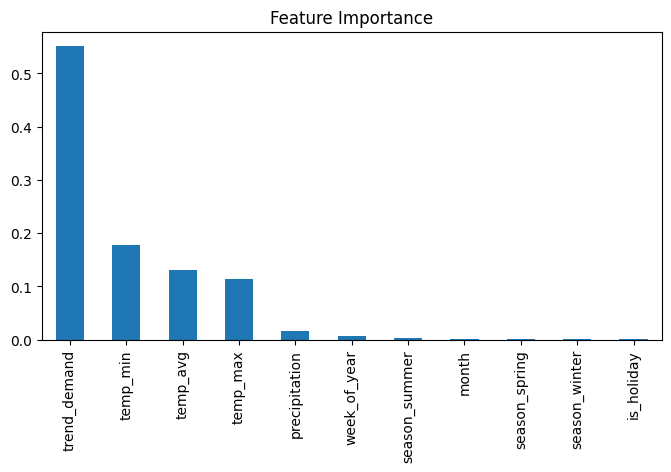

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar", figsize=(8,4))
plt.title("Feature Importance")
plt.show()